In [8]:
# 1. Instalación
!pip install -q segmentation-models-pytorch albumentations

You should consider upgrading via the 'c:\users\user\appdata\local\programs\python\python39\python.exe -m pip install --upgrade pip' command.


In [9]:
import sys
print(sys.executable)

c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [3]:
%pip install numpy pandas opencv-python matplotlib torch torchvision albumentations segmentation-models-pytorch scikit-learn ipykernel

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
     ---------------------------------------- 0.0/646.3 kB ? eta -:--:--
     ---------------------------------------- 646.3/646.3 kB 7.6 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata

  error: subprocess-exited-with-error
  
  × Building wheel for stringzilla (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [10 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build\lib.win-amd64-cpython-314\cli
      copying cli\split.py -> build\lib.win-amd64-cpython-314\cli
      copying cli\wc.py -> build\lib.win-amd64-cpython-314\cli
      copying cli\__init__.py -> build\lib.win-amd64-cpython-314\cli
      running build_ext
      building 'stringzilla' extension
      error: Microsoft Visual C++ 14.0 or greater is required. Get it with "Microsoft C++ Build Tools": https://visualstudio.microsoft.com/visual-cpp-build-tools/
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for stringzilla

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
error: fa

In [1]:
# 2. Importaciones
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

c:\Users\USER\segmentacion-vertebras-proyecto-maia\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# 3. Configuración
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 10
LR = 1e-3

In [4]:
image_paths = sorted(list(NORMAL_DIR.glob("*")) + list(SCOLIOSIS_DIR.glob("*")))
mask_paths = sorted(list(MASK_DIR.glob("*")))

NameError: name 'NORMAL_DIR' is not defined

In [5]:
from pathlib import Path
import os

DATASET_ROOT = Path(r"C:\Users\USER\MaIA_Scoliosis_Dataset")

NORMAL_DIR = DATASET_ROOT / "Normal"
SCOLIOSIS_DIR = DATASET_ROOT / "Scoliosis"
MASK_DIR = DATASET_ROOT / "LabelBinaryJPG"

# Todas las imágenes
all_images = list(NORMAL_DIR.glob("*")) + list(SCOLIOSIS_DIR.glob("*"))

# Diccionario de máscaras por nombre
mask_dict = {p.name: p for p in MASK_DIR.glob("*")}

image_paths = sorted([str(p) for p in all_images])
mask_paths = sorted([str(p) for p in MASK_DIR.glob("*")])

print(len(image_paths), len(mask_paths))

for img_path in all_images:
    if img_path.name in mask_dict:
        image_paths.append(str(img_path))
        mask_paths.append(str(mask_dict[img_path.name]))

print(f"Imágenes emparejadas: {len(image_paths)}")
print(f"Máscaras emparejadas: {len(mask_paths)}")
print("Ejemplo:")
print(image_paths[0])
print(mask_paths[0])

250 250
Imágenes emparejadas: 250
Máscaras emparejadas: 250
Ejemplo:
C:\Users\USER\MaIA_Scoliosis_Dataset\Normal\N_1.jpg
C:\Users\USER\MaIA_Scoliosis_Dataset\LabelBinaryJPG\Label_N_1.jpg


In [6]:
for i in range(5):
    print(os.path.basename(image_paths[i]), " <-> ", os.path.basename(mask_paths[i]))

N_1.jpg  <->  Label_N_1.jpg
N_10.jpg  <->  Label_N_10.jpg
N_11.jpg  <->  Label_N_11.jpg
N_12.jpg  <->  Label_N_12.jpg
N_13.jpg  <->  Label_N_13.jpg


In [7]:
class VertebrasDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        mask = self.rgb_to_binary(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image.float(), mask.unsqueeze(0).float()

    def rgb_to_binary(self, mask):
        return (np.sum(mask, axis=2) > 10).astype(np.float32)

In [10]:
# 5. Dataset
class VertebrasDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = cv2.imread(self.images[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(self.masks[idx])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        mask = self.rgb_to_binary(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        image = image.float()
        mask = mask.float()

        return image.float(), mask.unsqueeze(0).float()

    def rgb_to_binary(self, mask):
        # cualquier pixel con intensidad > 10 = vertebra
        return (np.sum(mask, axis=2) > 10).astype(np.float32)



In [9]:
# 6. Transformaciones

# Añade el paso de Normalize
transform_comun = [
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
]

train_transform = A.Compose([A.HorizontalFlip(p=0.5)] + transform_comun)
val_transform = A.Compose(transform_comun)

In [11]:
# 7. Split
train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=42
)

train_dataset = VertebrasDataset(train_imgs, train_masks, train_transform)
val_dataset = VertebrasDataset(val_imgs, val_masks, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [17]:
# 8. Modelo U-Net
model = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1
).to(DEVICE)

In [13]:
# 9. Loss y optimizador
loss_fn = smp.losses.DiceLoss(mode='binary', from_logits=True)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

In [14]:
# 10. Métrica Dice
def dice_score(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float()
    intersection = (preds * targets).sum()
    return (2 * intersection + smooth) / (preds.sum() + targets.sum() + smooth)


In [21]:
def dice_score(preds, targets, smooth=1e-6):
    preds = (preds > 0.5).float()
    
    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    dice = (2 * intersection + smooth) / (preds.sum(dim=1) + targets.sum(dim=1) + smooth)
    return dice.mean()

N_1.jpg <-> Label_N_1.jpg


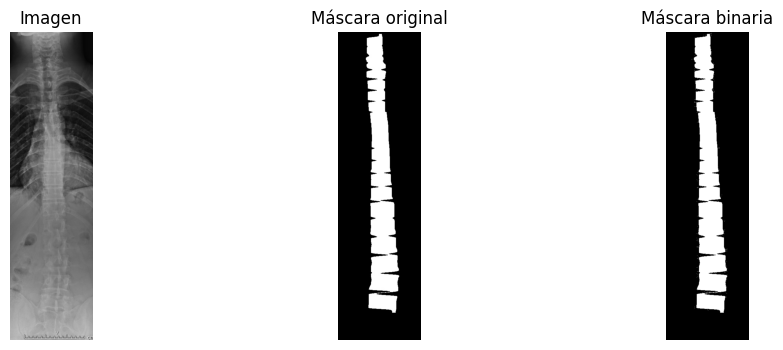

N_10.jpg <-> Label_N_10.jpg


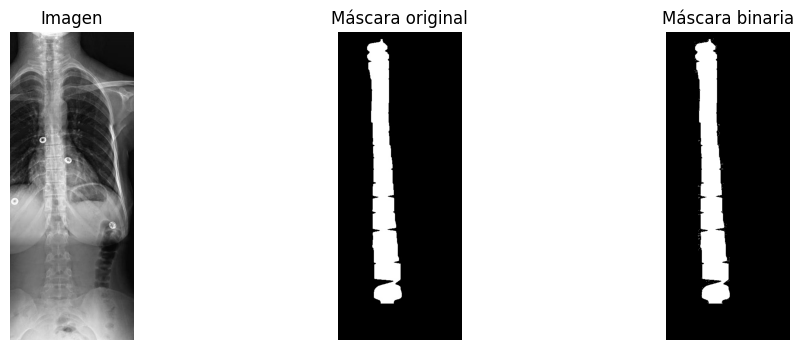

N_11.jpg <-> Label_N_11.jpg


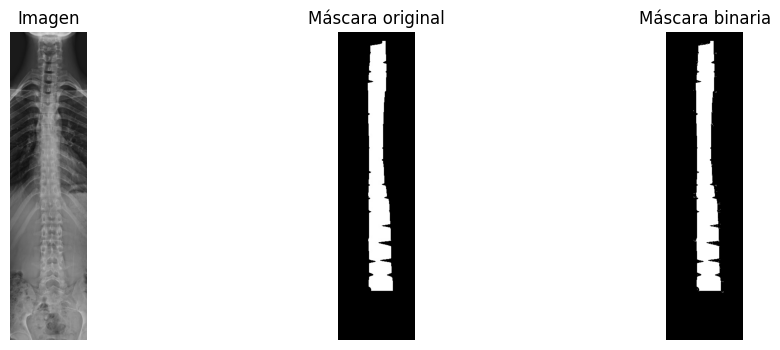

N_12.jpg <-> Label_N_12.jpg


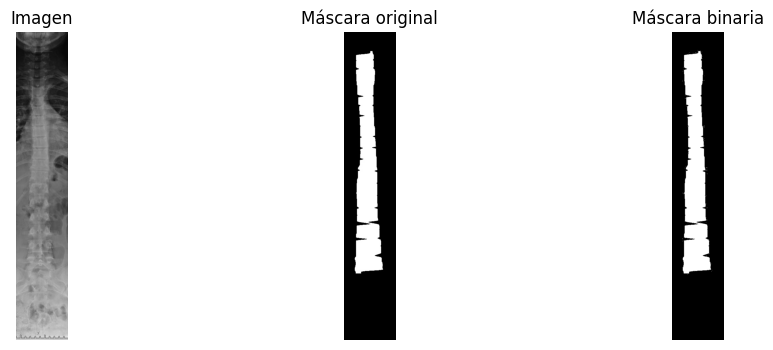

N_13.jpg <-> Label_N_13.jpg


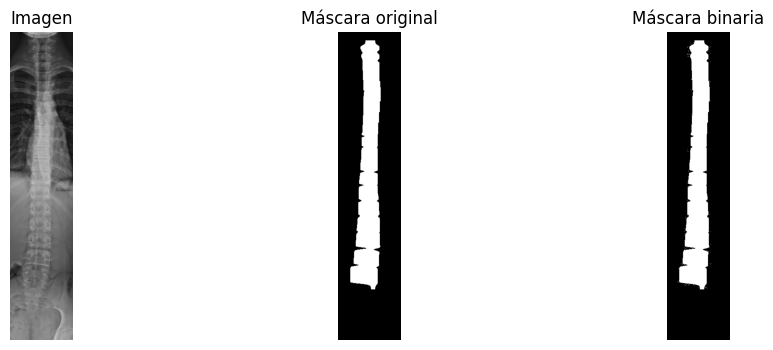

In [19]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

def show_pair(img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask_bin = (np.sum(mask, axis=2) > 10).astype(np.uint8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Imagen")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(mask)
    plt.title("Máscara original")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(mask_bin, cmap="gray")
    plt.title("Máscara binaria")
    plt.axis("off")

    plt.show()

for i in range(5):
    print(os.path.basename(image_paths[i]), "<->", os.path.basename(mask_paths[i]))
    show_pair(image_paths[i], mask_paths[i])

In [22]:
mask_ratios = []

for m in mask_paths[:100]:
    mask = cv2.imread(m)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    mask_bin = (np.sum(mask, axis=2) > 10).astype(np.float32)
    mask_ratios.append(mask_bin.mean())

print("Promedio de píxeles positivos:", np.mean(mask_ratios))
print("Mínimo:", np.min(mask_ratios))
print("Máximo:", np.max(mask_ratios))

Promedio de píxeles positivos: 0.17958763
Mínimo: 0.073575325
Máximo: 0.32329884


In [ ]:
# 11. Entrenamiento
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        preds = model(images)
        loss = loss_fn(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_dice = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            preds = torch.sigmoid(model(images))
            val_dice += dice_score(preds, masks)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss/len(train_loader):.4f}")
    print(f"Val Dice: {val_dice/len(val_loader):.4f}")


Epoch 1
Train Loss: 0.7692
Val Dice: 0.2150
Epoch 2
Train Loss: 0.7700
Val Dice: 0.2137
Epoch 3
Train Loss: 0.7684
Val Dice: 0.2194


In [ ]:
model.eval()

images, masks = next(iter(val_loader))
images = images.to(DEVICE)

with torch.no_grad():
    probs = torch.sigmoid(model(images))

preds = (probs > 0.5).float().cpu().numpy()
imgs = images.cpu().permute(0, 2, 3, 1).numpy()
true_masks = masks.numpy()

idx = 0
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow((imgs[idx] * 0.229 + 0.485).clip(0,1))  # aproximación si normalizaste con ImageNet
plt.title("Imagen")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(true_masks[idx,0], cmap="gray")
plt.title("Máscara real")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(preds[idx,0], cmap="gray")
plt.title("Predicción")
plt.axis("off")

plt.show()

In [31]:
# 12. Predicción
def predict_image(model, image_path, transform):
    model.eval()
    
    # Leer imagen original
    image_cv = cv2.imread(image_path)
    image_cv = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)
    h_orig, w_orig = image_cv.shape[:2] # Guardamos alto y ancho originales

    # Aplicar EXACTAMENTE la misma transformación de validación
    # Esto maneja el Resize y el ToTensorV2 correctamente
    augmented = transform(image=image_cv)
    image_tensor = augmented['image'].unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        output = model(image_tensor)
        # Aplicamos sigmoid para obtener probabilidades entre 0 y 1
        probs = torch.sigmoid(output)[0][0].cpu().numpy()

    # Escalar la predicción (mapa de probabilidades) al tamaño original
    # Usamos INTER_LINEAR para suavizar las probabilidades
    probs_orig_size = cv2.resize(probs, (w_orig, h_orig), interpolation=cv2.INTER_LINEAR)

    # Umbral (Threshold) estándar para segmentación binaria
    mask_binary = (probs_orig_size > 0.5).astype(np.uint8)

    return image_cv, mask_binary

In [32]:
# 13. Visualización
def plot_prediction(original, pred): 
    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.title("Imagen original")
    plt.imshow(original)
    plt.axis('off')
    
    plt.subplot(1,3,2)
    plt.title("Predicción (máscara)")
    plt.imshow(pred, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(original)
    plt.imshow(pred, alpha=0.5, cmap='jet')
    plt.axis('off')
    
    plt.show()

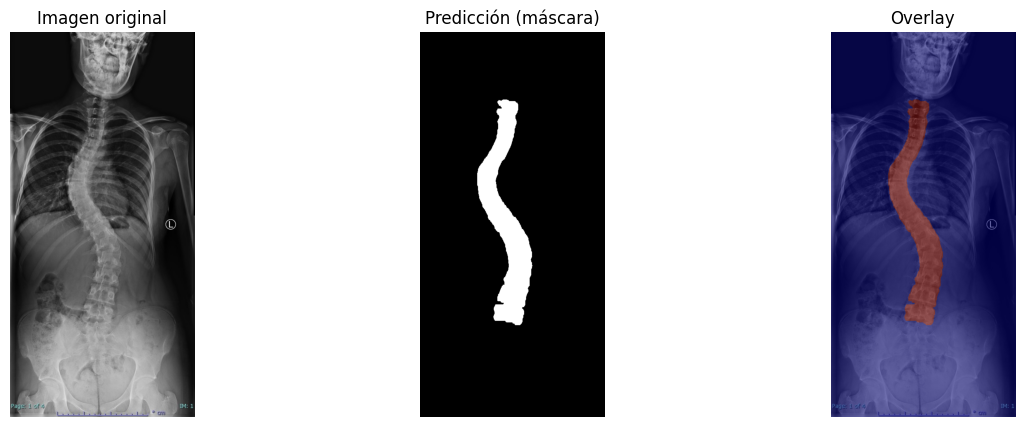

In [35]:
image_path = val_imgs[5]  # o cualquier imagen

original, pred = predict_image(model, image_path, val_transform)
plot_prediction(original, pred)

In [34]:
# Definir la ruta y nombre del archivo
MODEL_SAVE_PATH = "unet_resnet34_columna.pth"

# Guardar solo los pesos (es lo más eficiente y seguro)
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Modelo guardado exitosamente en: {MODEL_SAVE_PATH}")

Modelo guardado exitosamente en: unet_resnet34_columna.pth
